In [2]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784',version=1,as_frame=False)
X,y = mnist.data, mnist.target
X[2]

X.shape



(70000, 784)

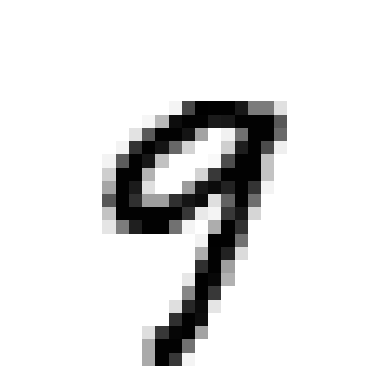

In [3]:
import matplotlib.pyplot as plt
def plot_digit(image_data):
    image = image_data.reshape(28,28)
    plt.imshow(image, cmap="binary")
    plt.axis('off')
some_digit = X[45]
plot_digit(some_digit)
plt.show()




In [4]:
y[0]

'5'

In [5]:
X_train, X_test, y_train, y_test = X[:60000],X[60000:],y[:60000],y[60000:]
y_train_5 = (y_train == '5')
y_test_5 = (y_test == '5')
X_train.shape
X_test.shape
y_train_5.shape
y_test_5.shape
print(y_train_5.shape, X_train.shape)



(60000,) (60000, 784)


In [6]:
from sklearn.linear_model import SGDClassifier

sdg_clf = SGDClassifier(random_state=42)
sdg_clf.fit(X_train,y_train_5)
sdg_clf.predict([some_digit])





array([False])

In [7]:
from sklearn.model_selection import cross_val_score
cross_val_score(sdg_clf,X_train,y_train_5,cv=3,scoring="accuracy")






array([0.95035, 0.96035, 0.9604 ])

In [8]:
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sdg_clf,X_train,y_train_5, cv=3)

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_train_5,y_train_pred)
print(cm)


[[53892   687]
 [ 1891  3530]]


In [9]:
y_train_perfect_predictions = y_train_5
cm2 = confusion_matrix(y_train_5,y_train_perfect_predictions)
print(cm2)


[[54579     0]
 [    0  5421]]


In [10]:
from sklearn.metrics import precision_score, recall_score
precision_score(y_train_5,y_train_pred)

0.8370879772350012

In [11]:
recall_score(y_train_5, y_train_pred)

0.6511713705958311

In [12]:
from sklearn.metrics import f1_score
f1_score(y_train_5,y_train_pred)

0.7325171197343847

In [13]:
y_scores = sdg_clf.decision_function([some_digit])
y_scores

array([-5893.27624997])

In [14]:
threshold = 0


In [15]:
y_some_digit_pred= 0

In [18]:
threshold=3000
y_some_digit_pred = (y_scores > threshold)
print(y_some_digit_pred)


[False]


In [25]:
from sklearn.metrics import precision_recall_curve
y_scores = cross_val_predict(sdg_clf,X_train, y_train_5, cv= 3, method= "decision_function")
precisions, recalls, thresholds = precision_recall_curve(y_train_5,y_scores)

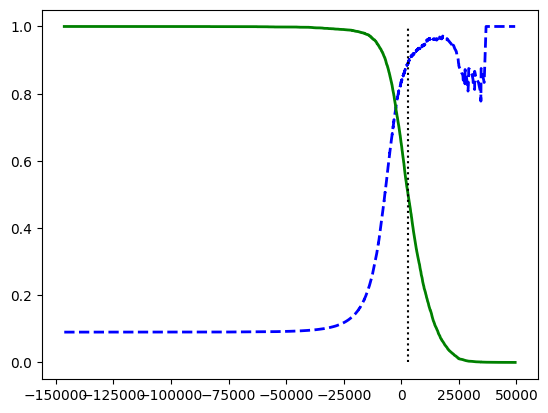

In [30]:
plt.plot(thresholds, precisions[:-1], "b--", label= "Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label= "Recall", linewidth=2)
plt.vlines(threshold, 0,1.0, "k", "dotted", label= "threshold")
[...]
plt.show()

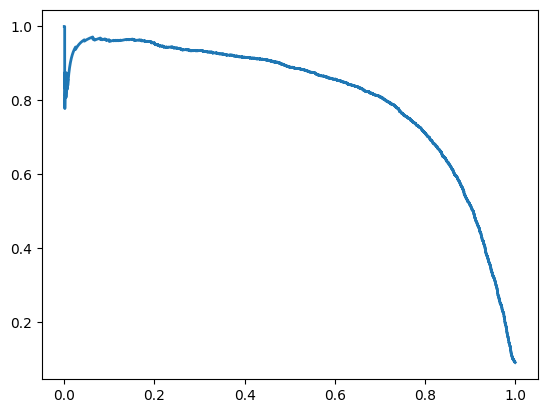

In [27]:
plt.plot(recalls,precisions,linewidth=2,label="precision/recall curve")
[...]
plt.show()


In [29]:
idx_for_90_precision = (precisions >= 0.90).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]
print(threshold_for_90_precision)


3370.0194991439557


In [31]:
y_train_pred_90= (y_scores >= threshold_for_90_precision )
precision_score = (y_train_5, y_train_pred_90)

recall_at_90_precision = recall_score(y_train_5, y_train_pred_90)

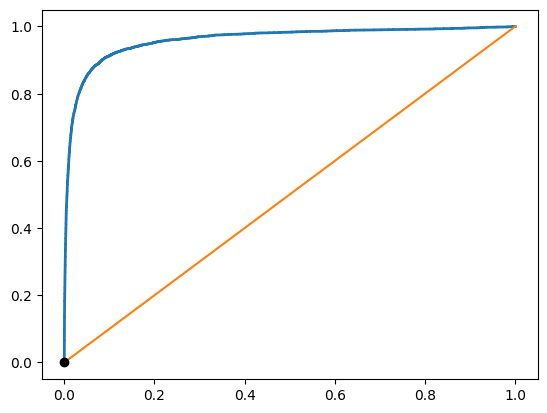

In [33]:
from sklearn.metrics import roc_curve
fpr, tpr, threshold = roc_curve(y_train_5, y_scores)
idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax()
tpr_90 , fpr_90, = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

plt.plot(fpr,tpr,linewidth=2, label = "roc curve")
plt.plot([0,1], [0,1], label = "random classifier roc curve")
plt.plot([fpr_90],[tpr_90], "ko", label = "threshold for 90% precision")
[...]
plt.show()

In [34]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_5, y_scores)


0.9604938554008616

In [36]:
from sklearn.ensemble import RandomForestClassifier
forest_clf = RandomForestClassifier(random_state=42)

y_probas_forest = cross_val_predict(forest_clf, X_train,y_train_5, cv=3, method= "predict_proba")
y_probas_forest[:2]

array([[0.11, 0.89],
       [0.99, 0.01]])

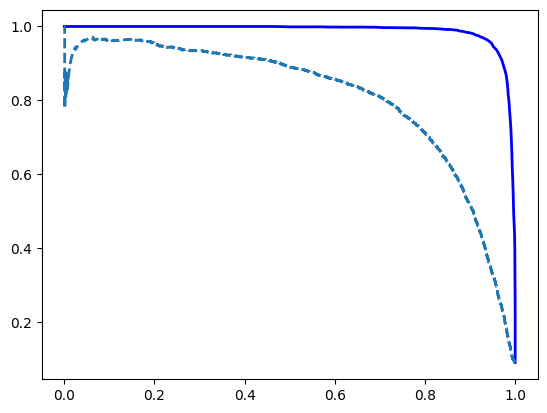

In [41]:
y_scores_forest = y_probas_forest[:,1]
precision_forest  , recall_forest, thresholds_forest = precision_recall_curve(y_train_5, y_scores_forest)
plt.plot(recall_forest,precision_forest, "b-", linewidth=2)

plt.plot(recalls, precisions, "--", linewidth=2, label = "SDG")
[...]
plt.show()

In [42]:
y_train_pred_forest = y_probas_forest[:,1] >= 0.5
f1_score(y_train_5,y_train_pred_forest)
roc_auc_score(y_train_5, y_scores_forest)

0.9983436731328145